# Hollywood Age Gap — BA820 B1 Team 10
Parisha Patel

In [1]:
!pip -q install yellowbrick

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

# M2: Director-Level Casting Patterns and Collaboration Structures

In this milestone, we shift the unit of analysis from **films/couples** to **directors**.

**Goal:** Identify whether directors form distinct groups based on:
1) **Age-gap casting profiles** (typical gap + variability + prevalence of extreme gaps), and  
2) **Collaboration concentration** (repeat work with the same actors vs broader actor pool).

This notebook proceeds in stages:
1. Data load + minimal preprocessing  
2. Mini-context EDA (only what supports M2 decisions)  
3. Director coverage & reliability filtering  
4. Director feature engineering (age-gap + collaboration)  
5. Unsupervised clustering (k diagnostics + hierarchical check)  
6. Cluster interpretation (prototypes + extremes)  
7. Robustness check (age-gap-only clustering)  
8. PCA visualization (2D + 3D)  
9. Limitations + next steps

In [2]:
# 1) Load + minimal prep
DATA_URL = "https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv"
df = pd.read_csv(DATA_URL)

# Target: age gap (years)
df["age_gap"] = pd.to_numeric(df["age_difference"], errors="coerce")

# Keep valid year + age_gap
df = df.dropna(subset=["release_year", "age_gap"]).copy()
df["release_year"] = df["release_year"].astype(int)

# Couple type label (for representation imbalance context)
df["pairing_type"] = (
    df["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    df["character_2_gender"].astype(str).str.strip().str.lower()
)

# Threshold flags (interpretable summaries)
LARGE_GAP = 20
PARITY_CUTOFF = 3
df["is_large_gap"] = df["age_gap"] >= LARGE_GAP
df["is_near_parity"] = df["age_gap"] <= PARITY_CUTOFF

print("Shape:", df.shape)
df.head()

Shape: (1155, 17)


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age,age_gap,pairing_type,is_large_gap,is_near_parity
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23,52,woman–man,True,False
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24,50,man–woman,True,False
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20,49,man–woman,True,False
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23,45,man–woman,True,False
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38,43,man–man,True,False


## 2) Mini-context EDA (kept intentionally small)

This section is *not* full M1-style EDA.  
We only keep context that helps interpret M2 decisions (coverage imbalance + representation skew + distribution shape).


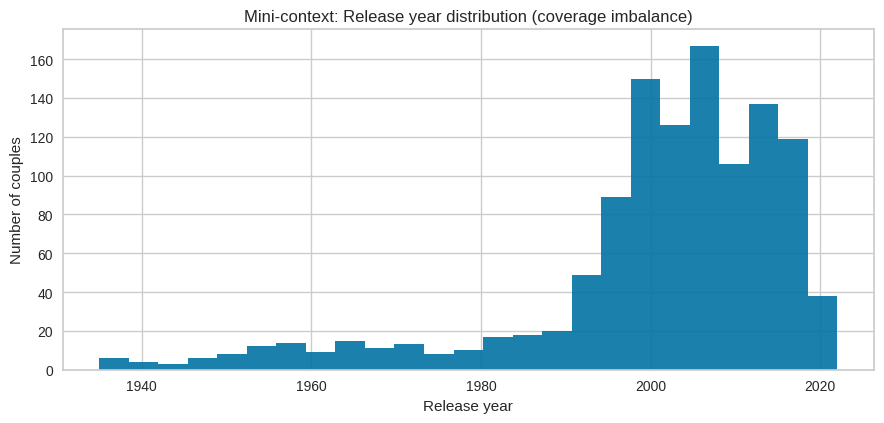

,pairing_type,count
0,man–woman,929
1,woman–man,203
2,man–man,12
3,woman–woman,11


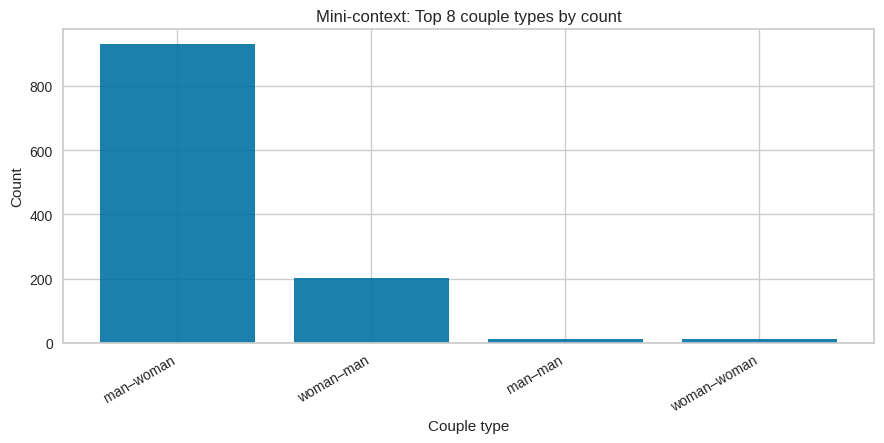

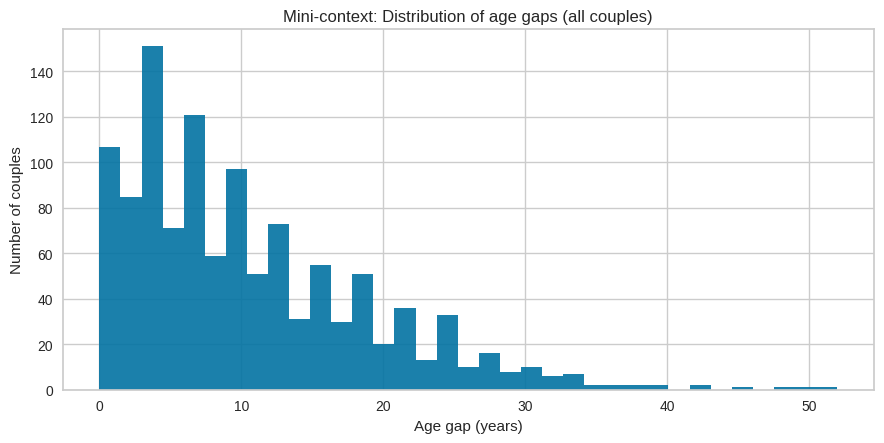

In [3]:
# (A) Release year coverage / imbalance
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(df["release_year"], bins=25, alpha=0.90)
ax.set_title("Mini-context: Release year distribution (coverage imbalance)")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of couples")
plt.tight_layout()
plt.show()

# (B) Couple-type representation imbalance
type_counts = (
    df["pairing_type"]
    .value_counts()
    .rename_axis("pairing_type")
    .reset_index(name="count")
)
display(type_counts)

top_n = 8
top_types = type_counts.head(top_n)

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(top_types["pairing_type"], top_types["count"], alpha=0.90)
ax.set_title(f"Mini-context: Top {top_n} couple types by count")
ax.set_xlabel("Couple type")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# (C) One distribution plot (pick histogram; skip boxplot to avoid redundancy)
age_gap_series = df["age_gap"].dropna()

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(age_gap_series, bins=35, alpha=0.90)
ax.set_title("Mini-context: Distribution of age gaps (all couples)")
ax.set_xlabel("Age gap (years)")
ax.set_ylabel("Number of couples")
plt.tight_layout()
plt.show()

## 3) Director coverage and reliability filtering

Many directors appear only once or twice. Director-level clustering is more meaningful when profiles reflect repeated behavior.

We retain directors with at least **MIN_COUPLES** romantic couples recorded.

Director coverage summary:


,num_couples
count,510.000000
mean,2.264706
std,2.056789
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,20.000000


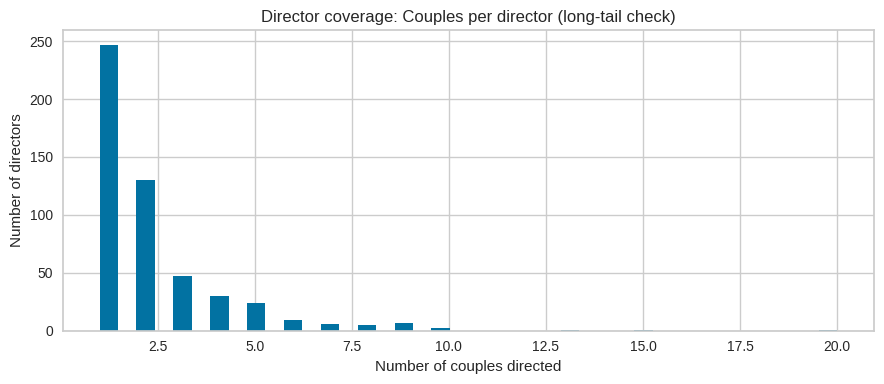

Directors retained: 56
Couples retained: 387


In [4]:
director_counts = (
    df.groupby("director")
      .size()
      .rename("num_couples")
      .sort_values(ascending=False)
)

print("Director coverage summary:")
display(director_counts.describe())

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(director_counts.values, bins=40)
ax.set_title("Director coverage: Couples per director (long-tail check)")
ax.set_xlabel("Number of couples directed")
ax.set_ylabel("Number of directors")
plt.tight_layout()
plt.show()

MIN_COUPLES = 5
eligible_directors = director_counts[director_counts >= MIN_COUPLES].index
df_dir = df[df["director"].isin(eligible_directors)].copy()

print(f"Directors retained: {df_dir['director'].nunique()}")
print(f"Couples retained: {len(df_dir)}")

## 4) Director-level feature engineering

We create two feature families:

### A) Age-gap profile features
- `median_gap`, `mean_gap`, `gap_std`
- `pct_large_gap` (share of couples with gap ≥ 20)

### B) Collaboration concentration features
We use actor-name recurrence as a proxy for concentrated ecosystems.

**Important adjustment:** raw repetition measures can be confounded by how many couples a director has.
So we add normalized measures:
- `max_actor_repeats_per_couple = max_actor_repeats / num_couples`
- `unique_actors_per_link = unique_actors / (2 * num_couples)`  (since two actors per couple)

In [5]:
# A) Age-gap profile per director
director_age_profile = (
    df_dir
    .groupby("director")
    .agg(
        median_gap=("age_gap", "median"),
        mean_gap=("age_gap", "mean"),
        gap_std=("age_gap", "std"),
        num_couples=("age_gap", "size"),
        pct_large_gap=("is_large_gap", "mean")
    )
    .reset_index()
)

# B) Collaboration stats: stack actors long
actors_long = pd.concat([
    df_dir[["director", "actor_1_name"]].rename(columns={"actor_1_name": "actor"}),
    df_dir[["director", "actor_2_name"]].rename(columns={"actor_2_name": "actor"})
], ignore_index=True)

actor_repeat_stats = (
    actors_long
    .groupby(["director", "actor"])
    .size()
    .rename("collab_count")
    .reset_index()
)

director_actor_stats = (
    actor_repeat_stats
    .groupby("director")
    .agg(
        unique_actors=("actor", "nunique"),
        total_actor_links=("collab_count", "sum"),
        max_actor_repeats=("collab_count", "max"),
    )
    .reset_index()
)

# Combine
director_eda = director_age_profile.merge(director_actor_stats, on="director", how="left")

# Normalized collab features (reduce confounding by num_couples)
director_eda["max_actor_repeats_per_couple"] = director_eda["max_actor_repeats"] / director_eda["num_couples"]
director_eda["unique_actors_per_link"] = director_eda["unique_actors"] / (2 * director_eda["num_couples"])

# Clean formatting for display
display(
    director_eda.sort_values("median_gap", ascending=False).head(10)
)

,director,median_gap,mean_gap,gap_std,num_couples,pct_large_gap,unique_actors,total_actor_links,max_actor_repeats,max_actor_repeats_per_couple,unique_actors_per_link
1,Alfred Hitchcock,22.0,21.000000,5.228129,7,0.857143,10,14,3,0.428571,0.714286
22,John Huston,21.5,18.500000,9.137833,6,0.500000,9,12,3,0.500000,0.750000
20,John Glen,21.0,19.866667,7.308182,15,0.533333,17,30,8,0.533333,0.566667
25,Lewis Gilbert,20.0,17.000000,6.271629,7,0.571429,9,14,4,0.571429,0.642857
55,Woody Allen,18.5,20.150000,11.263705,20,0.450000,27,40,7,0.350000,0.675000
54,Wes Anderson,18.0,13.800000,9.093954,5,0.400000,8,10,2,0.400000,0.800000
12,Garry Marshall,18.0,14.800000,7.726578,5,0.000000,7,10,2,0.400000,0.700000
14,Guy Hamilton,18.0,16.222222,7.310571,9,0.444444,11,18,5,0.555556,0.611111
16,Ivan Reitman,17.0,13.200000,10.592450,5,0.200000,9,10,2,0.400000,0.900000
9,David O. Russell,13.0,10.400000,6.580274,5,0.000000,6,10,4,0.800000,0.600000


### Quick EDA check at director level (interpretive, not causal)

Do directors with larger typical gaps also show more concentrated collaborations?

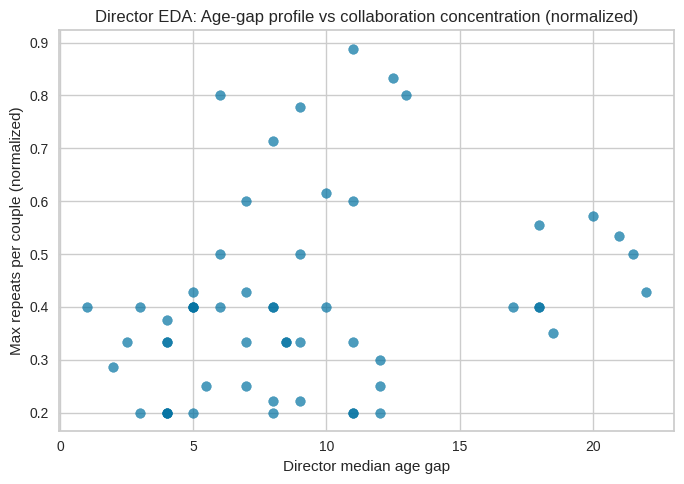

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    director_eda["median_gap"],
    director_eda["max_actor_repeats_per_couple"],
    alpha=0.7
)
ax.set_xlabel("Director median age gap")
ax.set_ylabel("Max repeats per couple (normalized)")
ax.set_title("Director EDA: Age-gap profile vs collaboration concentration (normalized)")
plt.tight_layout()
plt.show()

## 5) Unsupervised clustering

We cluster directors using standardized features and select k using:
- silhouette scores (manual loop),
- Yellowbrick visual diagnostics,
- cluster size sanity check.

We also run **hierarchical clustering (Ward linkage)** as a method robustness check.


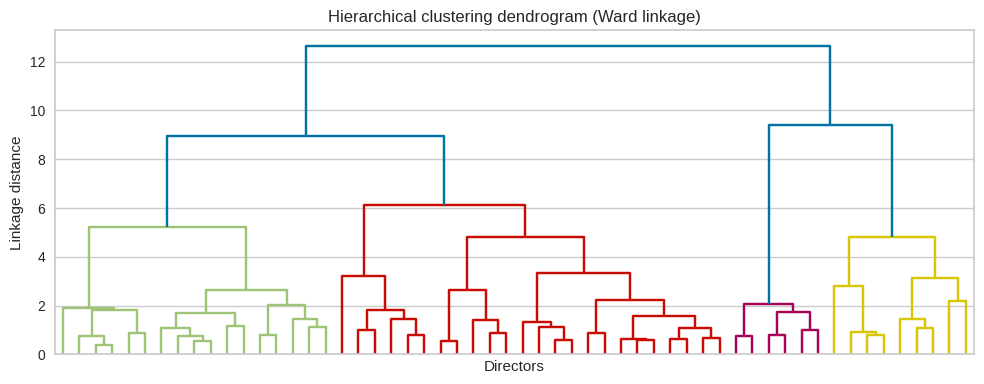

In [7]:
# Features for clustering (include normalized collab metrics)
feature_cols = [
    "median_gap",
    "gap_std",
    "pct_large_gap",
    "max_actor_repeats_per_couple",
    "unique_actors_per_link"
]

X = director_eda[feature_cols].copy().fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hierarchical clustering (Ward)
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(10, 4))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.xlabel("Directors")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.show()

,k,silhouette,min_cluster_size,max_cluster_size
0,2,0.350731,16,40
1,3,0.351435,7,39
2,4,0.304834,7,25
3,5,0.299678,7,22
4,6,0.291978,7,13
5,7,0.283924,4,14


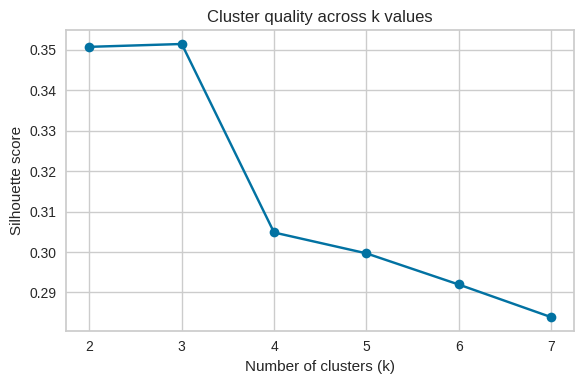

In [8]:
# Manual silhouette scan + cluster size sanity check
silhouette_results = {}
size_summaries = {}

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_scaled)
    silhouette_results[k] = silhouette_score(X_scaled, labels)

    # size sanity check
    counts = pd.Series(labels).value_counts().sort_index()
    size_summaries[k] = {
        "min_cluster_size": int(counts.min()),
        "max_cluster_size": int(counts.max()),
        "num_clusters": int(counts.size)
    }

silhouette_df = (
    pd.DataFrame({
        "k": list(silhouette_results.keys()),
        "silhouette": list(silhouette_results.values()),
        "min_cluster_size": [size_summaries[k]["min_cluster_size"] for k in silhouette_results],
        "max_cluster_size": [size_summaries[k]["max_cluster_size"] for k in silhouette_results],
    })
    .sort_values("k")
)

display(silhouette_df)

plt.figure(figsize=(6,4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Cluster quality across k values")
plt.tight_layout()
plt.show()

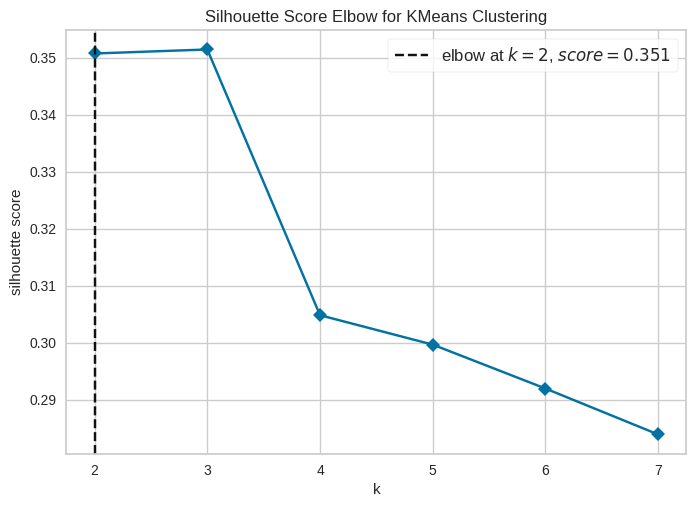

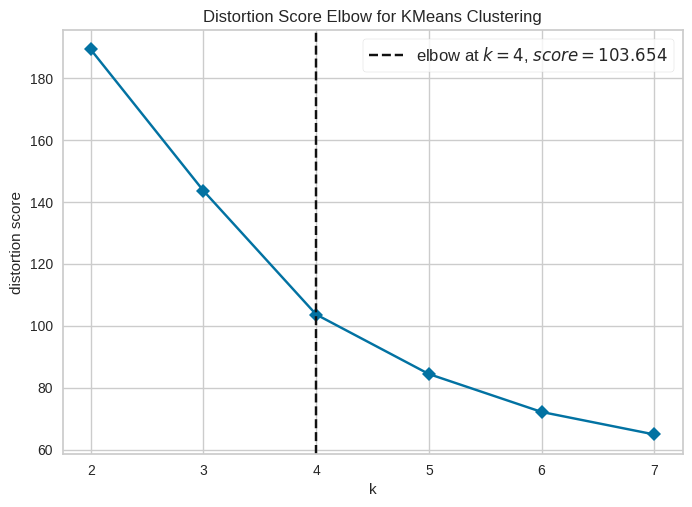

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [9]:
# Yellowbrick diagnostics
kmeans_model = KMeans(random_state=RANDOM_STATE, n_init=25)

visualizer = KElbowVisualizer(
    kmeans_model,
    k=(2, 8),
    metric="silhouette",
    timings=False
)
visualizer.fit(X_scaled)
visualizer.show()

visualizer = KElbowVisualizer(
    kmeans_model,
    k=(2, 8),
    metric="distortion",
    timings=False
)
visualizer.fit(X_scaled)
visualizer.show()

### Choose k (balanced: silhouette + interpretability + no tiny clusters)

We default to the k with the best silhouette, **unless** it produces very small clusters.


In [10]:
# Default: best silhouette
k_best = int(silhouette_df.sort_values("silhouette", ascending=False).iloc[0]["k"])

# Optional guardrail: avoid tiny clusters (change threshold if you want)
TINY_CLUSTER_THRESHOLD = 4
if silhouette_df[silhouette_df["k"] == k_best]["min_cluster_size"].iloc[0] < TINY_CLUSTER_THRESHOLD:
    # pick best silhouette among ks that meet size constraint
    candidates = silhouette_df[silhouette_df["min_cluster_size"] >= TINY_CLUSTER_THRESHOLD]
    k_final = int(candidates.sort_values("silhouette", ascending=False).iloc[0]["k"]) if len(candidates) else k_best
else:
    k_final = k_best

print("k_best (silhouette):", k_best)
print("k_final (with size check):", k_final)

kmeans = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=25)
director_eda["cluster"] = kmeans.fit_predict(X_scaled)
director_eda[["director", "cluster"]].head()

k_best (silhouette): 3
k_final (with size check): 3


,director,cluster
0,Adrian Lyne,0
1,Alfred Hitchcock,2
2,Andy Tennant,0
3,Ang Lee,0
4,"Bobby Farrelly, Peter Farrelly",1


In [11]:
# Cluster summary (means of features by cluster)
cluster_summary = (
    director_eda
    .groupby("cluster")
    .agg(
        n_directors=("director", "count"),
        median_gap=("median_gap", "mean"),
        gap_std=("gap_std", "mean"),
        pct_large_gap=("pct_large_gap", "mean"),
        max_actor_repeats_per_couple=("max_actor_repeats_per_couple", "mean"),
        unique_actors_per_link=("unique_actors_per_link", "mean"),
        num_couples=("num_couples", "mean"),
    )
    .round(3)
    .sort_index()
)

display(cluster_summary)

,n_directors,median_gap,gap_std,pct_large_gap,max_actor_repeats_per_couple,unique_actors_per_link,num_couples
cluster,,,,,,,
0,39,6.949,7.438,0.123,0.320,0.857,6.385
1,10,10.550,6.877,0.063,0.703,0.659,6.900
2,7,19.857,7.945,0.537,0.477,0.680,9.857


### Silhouette plot (separation diagnostic)

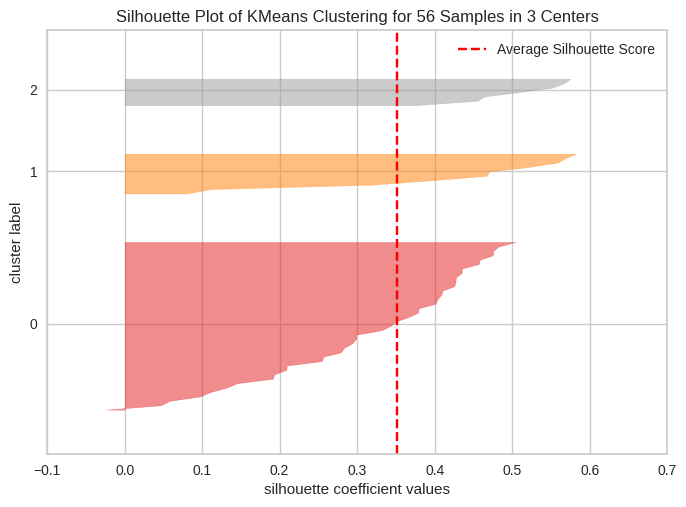

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 56 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [12]:
kmeans_for_viz = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=25)
viz = SilhouetteVisualizer(kmeans_for_viz, timings=False)
viz.fit(X_scaled)
viz.show()

## 6) Cluster interpretation: prototypes + extremes

We add interpretability by:
- showing **prototypes** (directors closest to each cluster centroid), and
- listing **extreme** directors within each cluster (highest median gap, highest large-gap share, most concentrated collab).

In [13]:
# Prototypes: closest to centroid (in standardized space)
centers = kmeans.cluster_centers_  # already in standardized feature space

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols, index=director_eda.index)

prototypes = []
for c in range(k_final):
    center = centers[c]
    idxs = director_eda.index[director_eda["cluster"] == c]
    dists = np.linalg.norm(X_scaled_df.loc[idxs].values - center, axis=1)
    closest = idxs[np.argsort(dists)[:5]]
    prototypes.append(
        director_eda.loc[closest, ["director", "cluster", "num_couples"] + feature_cols]
        .assign(role="prototype")
    )

prototypes_df = pd.concat(prototypes, ignore_index=True)
display(prototypes_df.sort_values(["cluster", "num_couples"], ascending=[True, False]).head(25))

,director,cluster,num_couples,median_gap,gap_std,pct_large_gap,max_actor_repeats_per_couple,unique_actors_per_link,role
1,Rob Reiner,0,9,8.0,7.747760,0.111111,0.222222,0.888889,prototype
2,Judd Apatow,0,8,4.0,6.311837,0.125000,0.375000,0.875000,prototype
4,Federico Fellini,0,7,7.0,6.924766,0.142857,0.428571,0.785714,prototype
0,Peter Segal,0,6,8.5,7.916228,0.166667,0.333333,0.833333,prototype
3,"Glenn Ficarra, John Requa",0,5,8.0,8.173127,0.200000,0.400000,0.900000,prototype
8,Martin Scorsese,1,13,10.0,9.277765,0.153846,0.615385,0.653846,prototype
5,Dennis Dugan,1,9,9.0,6.855655,0.111111,0.777778,0.666667,prototype
6,Christopher Nolan,1,7,8.0,5.047394,0.000000,0.714286,0.642857,prototype
9,Tim Burton,1,6,12.5,8.594572,0.166667,0.833333,0.666667,prototype
7,David O. Russell,1,5,13.0,6.580274,0.000000,0.800000,0.600000,prototype


In [14]:
# Extremes per cluster
def extremes_in_cluster(df_in, cluster_id):
    sub = df_in[df_in["cluster"] == cluster_id].copy()

    top_gap = sub.nlargest(5, "median_gap")[["director", "cluster", "num_couples", "median_gap", "pct_large_gap"]]
    top_large_share = sub.nlargest(5, "pct_large_gap")[["director", "cluster", "num_couples", "median_gap", "pct_large_gap"]]
    top_concentration = sub.nlargest(5, "max_actor_repeats_per_couple")[["director", "cluster", "num_couples", "max_actor_repeats_per_couple", "unique_actors_per_link"]]

    return top_gap, top_large_share, top_concentration

for c in range(k_final):
    print(f"\n==================== Cluster {c} ====================")
    tg, tls, tc = extremes_in_cluster(director_eda, c)

    print("\nTop 5 by median_gap:")
    display(tg)

    print("\nTop 5 by pct_large_gap:")
    display(tls)

    print("\nTop 5 by collaboration concentration (normalized):")
    display(tc)


==================== Cluster 0 ====================

Top 5 by median_gap:


,director,cluster,num_couples,median_gap,pct_large_gap
16,Ivan Reitman,0,5,17.0,0.200
26,Marc Forster,0,5,12.0,0.000
38,Richard Curtis,0,8,12.0,0.125
48,Steven Spielberg,0,10,12.0,0.300
19,Joel Coen,0,5,11.0,0.400



Top 5 by pct_large_gap:


,director,cluster,num_couples,median_gap,pct_large_gap
19,Joel Coen,0,5,11.0,0.400000
53,Tony Scott,0,5,5.0,0.400000
0,Adrian Lyne,0,6,8.5,0.333333
48,Steven Spielberg,0,10,12.0,0.300000
35,Paul Thomas Anderson,0,8,7.0,0.250000



Top 5 by collaboration concentration (normalized):


...

,director,cluster,num_couples,median_gap,pct_large_gap
1,Alfred Hitchcock,2,7,22.0,0.857143
22,John Huston,2,6,21.5,0.500000
20,John Glen,2,15,21.0,0.533333
25,Lewis Gilbert,2,7,20.0,0.571429
55,Woody Allen,2,20,18.5,0.450000



Top 5 by pct_large_gap:


,director,cluster,num_couples,median_gap,pct_large_gap
1,Alfred Hitchcock,2,7,22.0,0.857143
25,Lewis Gilbert,2,7,20.0,0.571429
20,John Glen,2,15,21.0,0.533333
22,John Huston,2,6,21.5,0.500000
55,Woody Allen,2,20,18.5,0.450000



Top 5 by collaboration concentration (normalized):


,director,cluster,num_couples,max_actor_repeats_per_couple,unique_actors_per_link
25,Lewis Gilbert,2,7,0.571429,0.642857
14,Guy Hamilton,2,9,0.555556,0.611111
20,John Glen,2,15,0.533333,0.566667
22,John Huston,2,6,0.500000,0.750000
1,Alfred Hitchcock,2,7,0.428571,0.714286


## 7) Robustness check: clustering using age-gap features only

We repeat clustering using only age-gap profile features and compare assignments to see whether collaboration features materially change group structure.

In [15]:
age_gap_only_cols = ["median_gap", "gap_std", "pct_large_gap"]
X_gap_only = director_eda[age_gap_only_cols].fillna(0)

X_gap_scaled = StandardScaler().fit_transform(X_gap_only)

km_gap_only = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=25)
director_eda["cluster_gap_only"] = km_gap_only.fit_predict(X_gap_scaled)

comparison = pd.crosstab(
    director_eda["cluster"],
    director_eda["cluster_gap_only"],
    normalize="index"
)

display(comparison)

cluster_gap_only,0,1,2
cluster,,,
0,0.0,0.615385,0.384615
1,0.0,0.700000,0.300000
2,1.0,0.000000,0.000000


## 8) PCA visualization (2D + 3D)

PCA is used only to visualize structure, not to define clusters.

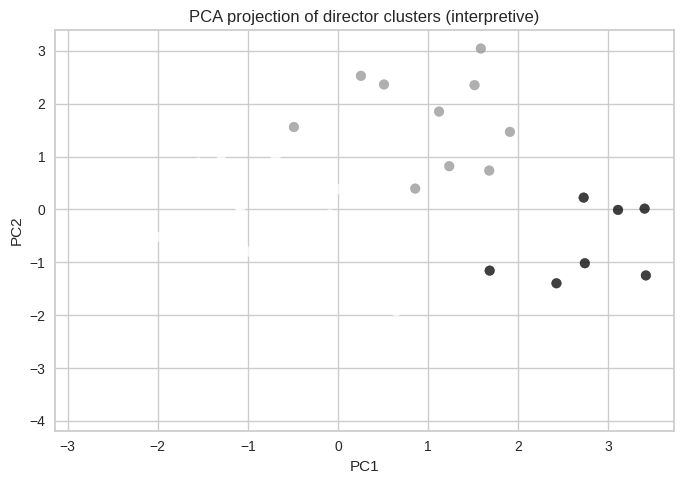

,0
PC1,0.45
PC2,0.32


In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

director_eda["pc1"] = X_pca[:, 0]
director_eda["pc2"] = X_pca[:, 1]

plt.figure(figsize=(7,5))
plt.scatter(
    director_eda["pc1"],
    director_eda["pc2"],
    c=director_eda["cluster"],
    alpha=0.75
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA projection of director clusters (interpretive)")
plt.tight_layout()
plt.show()

display(pd.Series(pca.explained_variance_ratio_, index=["PC1", "PC2"]).round(3))

In [17]:
# 3D visualization: pc1, pc2, plus an interpretable feature (median_gap)
fig = px.scatter_3d(
    director_eda,
    x="pc1",
    y="pc2",
    z="median_gap",
    color="cluster",
    hover_name="director"
)
fig.update_traces(marker_size=4)
fig.show()